In [1]:
pip install statsmodels

   ---------------------------------------- 0.0/9.5 MB ? eta -:--:--
   - -------------------------------------- 0.3/9.5 MB ? eta -:--:--
   --- ------------------------------------ 0.8/9.5 MB 2.7 MB/s eta 0:00:04
   ----- ---------------------------------- 1.3/9.5 MB 2.9 MB/s eta 0:00:03
   ----- ---------------------------------- 1.3/9.5 MB 2.9 MB/s eta 0:00:03
   ------ --------------------------------- 1.6/9.5 MB 1.8 MB/s eta 0:00:05
   ------ --------------------------------- 1.6/9.5 MB 1.8 MB/s eta 0:00:05
   ------- -------------------------------- 1.8/9.5 MB 1.4 MB/s eta 0:00:06
   ---------- ----------------------------- 2.6/9.5 MB 1.6 MB/s eta 0:00:05
   -------------- ------------------------- 3.4/9.5 MB 1.8 MB/s eta 0:00:04
   ----------------- ---------------------- 4.2/9.5 MB 2.0 MB/s eta 0:00:03
   -------------------- ------------------- 5.0/9.5 MB 2.2 MB/s eta 0:00:03
   ------------------------ --------------- 5.8/9.5 MB 2.3 MB/s eta 0:00:02
   -----------------------

2.1 Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from statsmodels.stats.outliers_influence import variance_inflation_factor

2.2 Load Data

In [2]:
df = pd.read_csv("C:/Users/Admin/Pandas Practice/data/seaborn_data/heart.csv")

In [3]:
df

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,52,1,0,125,212,0,1,168,0,1.0,2,2,3,0
1,53,1,0,140,203,1,0,155,1,3.1,0,0,3,0
2,70,1,0,145,174,0,1,125,1,2.6,0,0,3,0
3,61,1,0,148,203,0,1,161,0,0.0,2,1,3,0
4,62,0,0,138,294,1,1,106,0,1.9,1,3,2,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1020,59,1,1,140,221,0,1,164,1,0.0,2,0,2,1
1021,60,1,0,125,258,0,0,141,1,2.8,1,1,3,0
1022,47,1,0,110,275,0,0,118,1,1.0,1,1,2,0
1023,50,0,0,110,254,0,0,159,0,0.0,2,0,2,1


2.3 Understand Data-:
Goal:
Check missing values
Understand columns
Check data types
Basic statistics

In [4]:
#df.info()
df.isnull().sum()

age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          0
thal        0
target      0
dtype: int64

2.4 Outlier Treatment
Why?

Extreme values can hurt model performance.

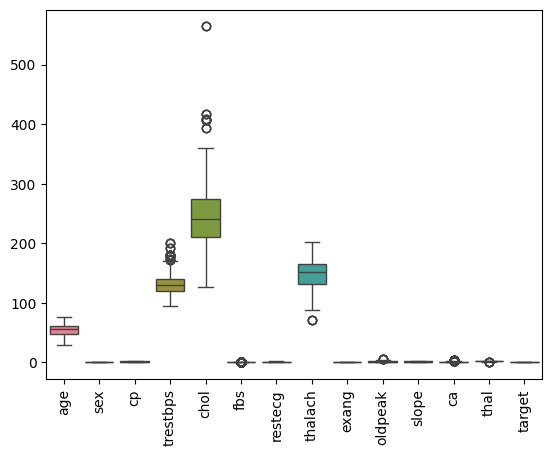

In [5]:
sns.boxplot(data=df)
plt.xticks(rotation=90)
plt.show()

In [11]:
df.describe()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
count,769.000000,769.000000,769.000000,769.000000,769.000000,769.0,769.000000,769.000000,769.000000,769.000000,769.000000,769.000000,769.000000,769.000000
mean,53.431730,0.691808,0.924577,128.685306,242.075423,0.0,0.551365,150.669701,0.323797,0.972432,1.438231,0.495449,2.331599,0.548765
std,9.225098,0.462047,1.019105,15.314066,44.521145,0.0,0.515667,22.567898,0.468228,1.050258,0.589973,0.705479,0.568764,0.497940
min,29.000000,0.000000,0.000000,94.000000,131.000000,0.0,0.000000,88.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000
25%,46.000000,0.000000,0.000000,120.000000,209.000000,0.0,0.000000,133.000000,0.000000,0.000000,1.000000,0.000000,2.000000,0.000000
50%,54.000000,1.000000,1.000000,130.000000,239.000000,0.0,1.000000,154.000000,0.000000,0.600000,1.000000,0.000000,2.000000,1.000000
75%,60.000000,1.000000,2.000000,140.000000,270.000000,0.0,1.000000,168.000000,1.000000,1.600000,2.000000,1.000000,3.000000,1.000000
max,76.000000,1.000000,3.000000,170.000000,360.000000,0.0,2.000000,202.000000,1.000000,4.000000,2.000000,2.000000,3.000000,1.000000


Remove outliers using IQR:

In [6]:
Q1 = df.quantile(0.25)
Q3 = df.quantile(0.75)
IQR = Q3 - Q1

df = df[~((df < (Q1 - 1.5 * IQR)) | (df > (Q3 + 1.5 * IQR))).any(axis=1)]

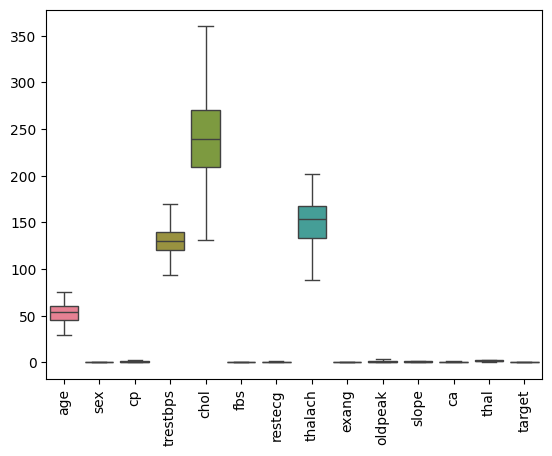

In [7]:
sns.boxplot(data=df)
plt.xticks(rotation=90)
plt.show()

2.5 Distribution of Target Variable
Goal:

Check if dataset is balanced.

Actually, for a medical dataset like this, your data is very well-balanced!
In the world of data, "imbalanced" usually means one bar is a giant tower and the other is a tiny blade of grass (like 95% vs 5%). 
Your bars are almost the same height:
Target 0 (No Heart Disease): ~350 patients  
Target 1 (Heart Disease): ~420 patients

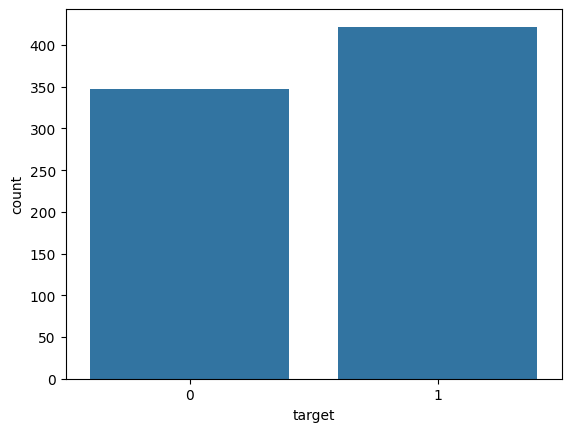

In [8]:
sns.countplot(x='target', data=df)
plt.show()

2.6 Correlation of Predictors with Target

Goal:

Understand which features matter most.

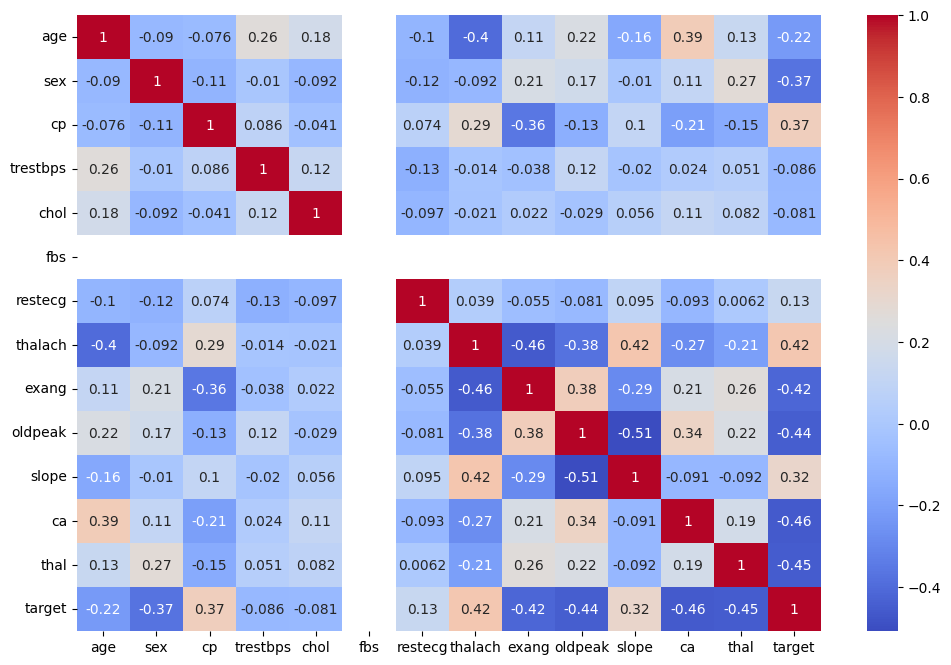

In [9]:
corr = df.corr()
plt.figure(figsize=(12,8))
sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.show()

2.8 Collinearity Check (VIF)

Why?

Highly correlated predictors reduce model quality.

Rule:
VIF > 10 → problematic

In [20]:
X = df.drop(["target","trestbps","chol","thalach","thal"] ,axis=1)

vif_data = pd.DataFrame()
vif_data["feature"] = X.columns
vif_data["VIF"] = [variance_inflation_factor(X.values, i) for i in range(X.shape[1])]

print(vif_data)

   feature        VIF
0      age  12.120321
1      sex   3.341435
2       cp   2.105504
3      fbs        NaN
4  restecg   2.139212
5    exang   1.999833
6  oldpeak   2.968172
7    slope   7.676738
8       ca   1.880577


c:\Program Files\Python313\Lib\site-packages\statsmodels\regression\linear_model.py:1784: RuntimeWarning: invalid value encountered in scalar divide
  return 1 - self.ssr/self.uncentered_tss


In [12]:
df.corr()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
age,1.000000,-0.089713,-0.076169,0.263557,0.176279,NaN,-0.103479,-0.398649,0.114700,0.219267,-0.161366,0.390240,0.131007,-0.220869
sex,-0.089713,1.000000,-0.113030,-0.010044,-0.091599,NaN,-0.116547,-0.092440,0.209085,0.170831,-0.010218,0.105541,0.270474,-0.367541
cp,-0.076169,-0.113030,1.000000,0.086497,-0.041429,NaN,0.074280,0.288103,-0.358065,-0.131628,0.104855,-0.205129,-0.152233,0.374184
trestbps,0.263557,-0.010044,0.086497,1.000000,0.123074,NaN,-0.125076,-0.014083,-0.037887,0.115325,-0.020313,0.023972,0.051163,-0.085923
chol,0.176279,-0.091599,-0.041429,0.123074,1.000000,NaN,-0.096983,-0.020648,0.022500,-0.028916,0.055897,0.110865,0.081953,-0.080868
fbs,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
restecg,-0.103479,-0.116547,0.074280,-0.125076,-0.096983,NaN,1.000000,0.038942,-0.055491,-0.081289,0.094971,-0.093310,0.006223,0.128416
thalach,-0.398649,-0.092440,0.288103,-0.014083,-0.020648,NaN,0.038942,1.000000,-0.455154,-0.376230,0.424558,-0.272514,-0.207425,0.416945
exang,0.114700,0.209085,-0.358065,-0.037887,0.022500,NaN,-0.055491,-0.455154,1.000000,0.379601,-0.288091,0.207471,0.261245,-0.416859
oldpeak,0.219267,0.170831,-0.131628,0.115325,-0.028916,NaN,-0.081289,-0.376230,0.379601,1.000000,-0.507931,0.343393,0.219786,-0.443599


In [18]:
X = df.drop(["target","trestbps","chol","thalach","thal"] ,axis=1)
Y=df["target"]

In [21]:
X_train,X_test,Y_train,Y_test=train_test_split(X,Y,test_size=0.2,random_state=42)

LOGISTIC REGRESSION MODEL
Best for baseline binary classification

In [31]:
lr = LogisticRegression()
lr.fit(X_train, Y_train)

y_pred_lr = lr.predict(X_test)

print("Accuracy:", accuracy_score(Y_test, y_pred_lr))
print(confusion_matrix(Y_test, y_pred_lr))
print(classification_report(Y_test, y_pred_lr))

Accuracy: 0.7987012987012987
[[45 19]
 [12 78]]
              precision    recall  f1-score   support

           0       0.79      0.70      0.74        64
           1       0.80      0.87      0.83        90

    accuracy                           0.80       154
   macro avg       0.80      0.78      0.79       154
weighted avg       0.80      0.80      0.80       154



DECISION TREE CLASSIFIER

In [24]:
dt = DecisionTreeClassifier()
dt.fit(X_train, Y_train)

y_pred_dt = dt.predict(X_test)

print("Accuracy:", accuracy_score(Y_test, y_pred_dt))

Accuracy: 0.9935064935064936


In [32]:
results = pd.DataFrame({
    'Model': ['Logistic Regression', 'Decision Tree'],
    'Accuracy': [
        accuracy_score(Y_test, y_pred_lr),
        accuracy_score(Y_test, y_pred_dt)
    ]
})

print(results)

                 Model  Accuracy
0  Logistic Regression  0.798701
1        Decision Tree  0.993506
